# Single Modality Testing
This notebook tests the predictive power of each modality independently:
- Clinical data only
- mRNA data only
- Mutation data only

In [42]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import config
from preprocessing_utils import ClinicalPreprocessorWrapper, MrnaPreprocessorWrapper, MutationPreprocessorWrapper
from model_utils import set_random_seed

# Set seeds for reproducibility
set_random_seed(seed=config.SEED, deterministic=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


## Hyperparameter Configuration
Set hyperparameters for each modality here. You can adjust these values manually.

In [43]:
# Hyperparameters for Clinical model
clinical_config = {
    "hidden_layers": [128],
    "dropout": [0.2, 0.2],
    "activation": "gelu",
    "lr": 5e-05,
    "optimizer": "AdamW",
    "weight_decay": 1.5e-06,
    "num_epochs": 13,  # Number of epochs to train
}

# Hyperparameters for mRNA model
mrna_config = {
    "hidden_layers": [128, 64],
    "dropout": [0.3, 0.3],
    "activation": "relu",
    "lr": 0.001,
    "optimizer": "Adam",
    "weight_decay": 0.0001,
    "num_epochs": 2,
}

# Hyperparameters for Mutation model
mutation_config = {
    "hidden_layers": [128, 64],
    "dropout": [0.3, 0.3],
    "activation": "relu",
    "lr": 0.001,
    "optimizer": "Adam",
    "weight_decay": 0.0001,
    "num_epochs": 6,
}

# Training configuration (shared)
training_config = {
    "batch_size": config.BATCH_SIZE,
    "threshold": 0.5,  # Fixed threshold for predictions
}

# Preprocessing configuration
preprocessing_config = {
    "max_mutation_count": 10,
    "mutation_uniform_thresh": 0.95,
}

print("Configuration loaded successfully!")

Configuration loaded successfully!


## Load Data

In [44]:
# Load data
print("Loading data...")
X_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_train.joblib"))
y_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_train.joblib"))

clinical_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "clinical_cols.joblib"))
mrna_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "mrna_cols.joblib"))
mutation_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "mutation_cols.joblib"))

# Split by modality
clinical_train = X_train[clinical_cols]
mrna_train = X_train[mrna_cols]
mutation_train = X_train[mutation_cols]

print(f"Data loaded: {len(X_train)} train samples")
print(f"Class distribution: {y_train.sum()} positive, {len(y_train) - y_train.sum()} negative")
print(f"Clinical features: {len(clinical_cols)}")
print(f"mRNA features: {len(mrna_cols)}")
print(f"Mutation features: {len(mutation_cols)}")

Loading data...
Data loaded: 147 train samples
Class distribution: 53.0 positive, 94.0 negative
Clinical features: 56
mRNA features: 20531
Mutation features: 19112


## Define Single Modality Model

In [45]:
class SingleModalityNet(nn.Module):
    """Neural network for single modality prediction"""
    def __init__(self, input_dim, hidden_layers, dropout, activation='relu'):
        super().__init__()
        
        # Build layers
        layers = []
        prev_dim = input_dim
        
        for i, hidden_dim in enumerate(hidden_layers):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            
            # Activation
            if activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'leaky_relu':
                layers.append(nn.LeakyReLU())
            elif activation == 'gelu':
                layers.append(nn.GELU())
            elif activation == 'silu':
                layers.append(nn.SiLU())
            
            # Dropout
            if i < len(dropout):
                layers.append(nn.Dropout(dropout[i]))
            
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze()


def to_loader(X, y, batch_size, shuffle=False):
    """Convert data to PyTorch DataLoader"""
    # Convert to numeric
    if isinstance(X, pd.DataFrame):
        X = X.to_numpy(dtype=np.float32)
    elif not isinstance(X, np.ndarray):
        X = np.array(X, dtype=np.float32)
    
    if isinstance(y, (pd.DataFrame, pd.Series)):
        y = y.to_numpy(dtype=np.float32)
    elif not isinstance(y, np.ndarray):
        y = np.array(y, dtype=np.float32)
    
    y = y.squeeze()
    
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def train_single_modality(X_train, y_train, model_config, training_config, modality_name):
    """Train a single modality model for a fixed number of epochs"""
    print(f"\n{'='*80}")
    print(f"Training {modality_name} Model")
    print(f"{'='*80}\n")
    
    # Get input dimension
    input_dim = X_train.shape[1]
    print(f"Input dimension: {input_dim}")
    print(f"Training for {model_config['num_epochs']} epochs")
    print(f"Using fixed threshold: {training_config['threshold']}")
    
    # Create model
    model = SingleModalityNet(
        input_dim=input_dim,
        hidden_layers=model_config['hidden_layers'],
        dropout=model_config['dropout'],
        activation=model_config['activation']
    ).to(device)
    
    print(f"\nModel architecture:")
    print(model)
    print()
    
    # Create optimizer
    if model_config['optimizer'] == 'Adam':
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=model_config['lr'],
            weight_decay=model_config['weight_decay']
        )
    elif model_config['optimizer'] == 'AdamW':
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=model_config['lr'],
            weight_decay=model_config['weight_decay']
        )
    elif model_config['optimizer'] == 'SGD':
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=model_config['lr'],
            weight_decay=model_config['weight_decay'],
            momentum=model_config.get('momentum', 0.9)
        )
    
    # Loss function with class imbalance handling
    pos_weight = torch.tensor(
        (len(y_train) - y_train.sum()) / y_train.sum(),
        dtype=torch.float32
    ).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    # Create data loader
    train_loader = to_loader(X_train, y_train, training_config['batch_size'], shuffle=True)
    
    # Training loop
    train_losses = []
    
    for epoch in range(model_config['num_epochs']):
        # Training
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{model_config['num_epochs']}: Loss={avg_loss:.4f}")
    
    # Evaluate on training set with fixed threshold
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            probs = torch.sigmoid(model(X_batch)).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y_batch.cpu().numpy())
    
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    
    # Calculate metrics on training set
    train_auroc = roc_auc_score(all_labels, all_probs)
    train_auprc = average_precision_score(all_labels, all_probs)
    
    # Use fixed threshold
    threshold = training_config['threshold']
    preds = (all_probs >= threshold).astype(int)
    train_f1 = f1_score(all_labels, preds, zero_division=0)
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, preds)
    
    # Final results
    print(f"\n{'='*80}")
    print(f"{modality_name} Model Training Results:")
    print(f"  Training AUROC: {train_auroc:.4f}")
    print(f"  Training F1: {train_f1:.4f}")
    print(f"  Training AUPRC: {train_auprc:.4f}")
    print(f"  Threshold: {threshold:.4f}")
    
    print(f"\n  Training Confusion Matrix:")
    print(f"    TN={cm[0,0]}, FP={cm[0,1]}")
    print(f"    FN={cm[1,0]}, TP={cm[1,1]}")
    print(f"{'='*80}\n")
    
    return {
        'model': model,
        'threshold': threshold,
        'train_metrics': {
            'auroc': train_auroc,
            'auprc': train_auprc,
            'f1': train_f1,
        },
        'training_history': {
            'train_losses': train_losses,
        }
    }

print("Model and training functions defined!")

Model and training functions defined!


## Preprocess Data

In [46]:
# Preprocess Clinical
print("Preprocessing clinical data...")
clinical_prep = ClinicalPreprocessorWrapper(
    cols_to_remove=config.CLINICAL_COLS_TO_REMOVE,
    categorical_cols=config.CATEGORICAL_COLS,
    max_null_frac=config.CLINICAL_MAX_NULL_FRAC,
    uniform_thresh=config.CLINICAL_UNIFORM_THRESH,
)
clinical_prep.fit(clinical_train)
clinical_train_prep = clinical_prep.transform(clinical_train)
print(f"Clinical: {clinical_train_prep.shape[1]} features after preprocessing")

# Preprocess mRNA
print("\nPreprocessing mRNA data...")
mrna_prep = MrnaPreprocessorWrapper(
    max_null_frac=config.MAX_NULL_FRAC,
    uniform_thresh=config.UNIFORM_THRESHOLD,
    random_state=config.SEED,
)
mrna_prep.fit(mrna_train, y_train)
mrna_train_prep = mrna_prep.transform(mrna_train)
print(f"mRNA: {mrna_train_prep.shape[1]} features after preprocessing")

# Preprocess Mutation
print("\nPreprocessing mutation data...")
mutation_prep = MutationPreprocessorWrapper(
    max_mutation_count=preprocessing_config['max_mutation_count'],
    uniform_thresh=preprocessing_config['mutation_uniform_thresh'],
)
mutation_prep.fit(mutation_train)
mutation_train_prep = mutation_prep.transform(mutation_train)
print(f"Mutation: {mutation_train_prep.shape[1]} features after preprocessing")

print("\nPreprocessing complete!")

Preprocessing clinical data...
Clinical: 40 features after preprocessing

Preprocessing mRNA data...
mRNA: 17507 features after preprocessing

Preprocessing mutation data...
Mutation: 9438 features after preprocessing

Preprocessing complete!


## Train Clinical Model

In [47]:
clinical_results = train_single_modality(
    clinical_train_prep, y_train,
    clinical_config,
    training_config,
    "Clinical"
)


Training Clinical Model

Input dimension: 40
Training for 13 epochs
Using fixed threshold: 0.5

Model architecture:
SingleModalityNet(
  (network): Sequential(
    (0): Linear(in_features=40, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

Epoch 1/13: Loss=2.0749
Epoch 10/13: Loss=1.4120

Clinical Model Training Results:
  Training AUROC: 0.7473
  Training F1: 0.5926
  Training AUPRC: 0.5627
  Threshold: 0.5000

  Training Confusion Matrix:
    TN=71, FP=23
    FN=21, TP=32



## Train mRNA Model

In [48]:
mrna_results = train_single_modality(
    mrna_train_prep, y_train,
    mrna_config,
    training_config,
    "mRNA"
)


Training mRNA Model

Input dimension: 17507
Training for 2 epochs
Using fixed threshold: 0.5

Model architecture:
SingleModalityNet(
  (network): Sequential(
    (0): Linear(in_features=17507, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Epoch 1/2: Loss=1.0326

mRNA Model Training Results:
  Training AUROC: 0.9663
  Training F1: 0.8522
  Training AUPRC: 0.9505
  Threshold: 0.5000

  Training Confusion Matrix:
    TN=81, FP=13
    FN=4, TP=49



## Train Mutation Model

In [49]:
mutation_results = train_single_modality(
    mutation_train_prep, y_train,
    mutation_config,
    training_config,
    "Mutation"
)


Training Mutation Model

Input dimension: 9438
Training for 6 epochs
Using fixed threshold: 0.5

Model architecture:
SingleModalityNet(
  (network): Sequential(
    (0): Linear(in_features=9438, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Epoch 1/6: Loss=0.8680

Mutation Model Training Results:
  Training AUROC: 0.9713
  Training F1: 0.2903
  Training AUPRC: 0.9722
  Threshold: 0.5000

  Training Confusion Matrix:
    TN=94, FP=0
    FN=44, TP=9



## Compare Results


SINGLE MODALITY COMPARISON (Training Set)

Modality    AUROC       F1    AUPRC
Clinical 0.747290 0.592593 0.562737
    mRNA 0.966279 0.852174 0.950528
Mutation 0.971297 0.290323 0.972162


Saved comparison plot to 'single_modality_comparison_training.png'


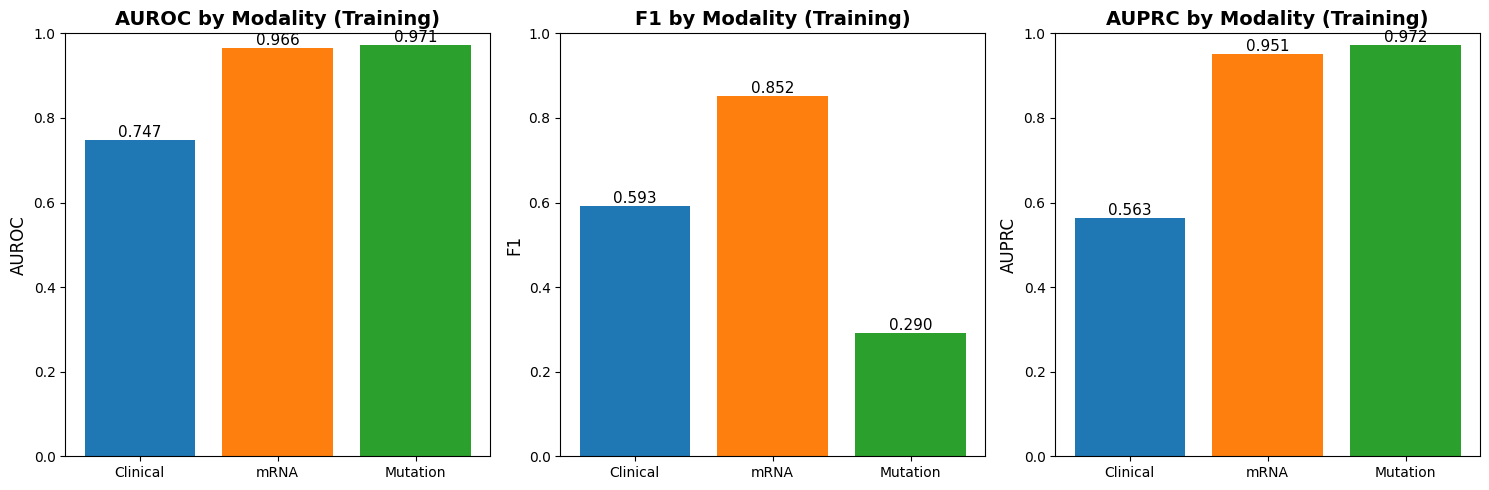

Saved training curves to 'single_modality_training_curves.png'


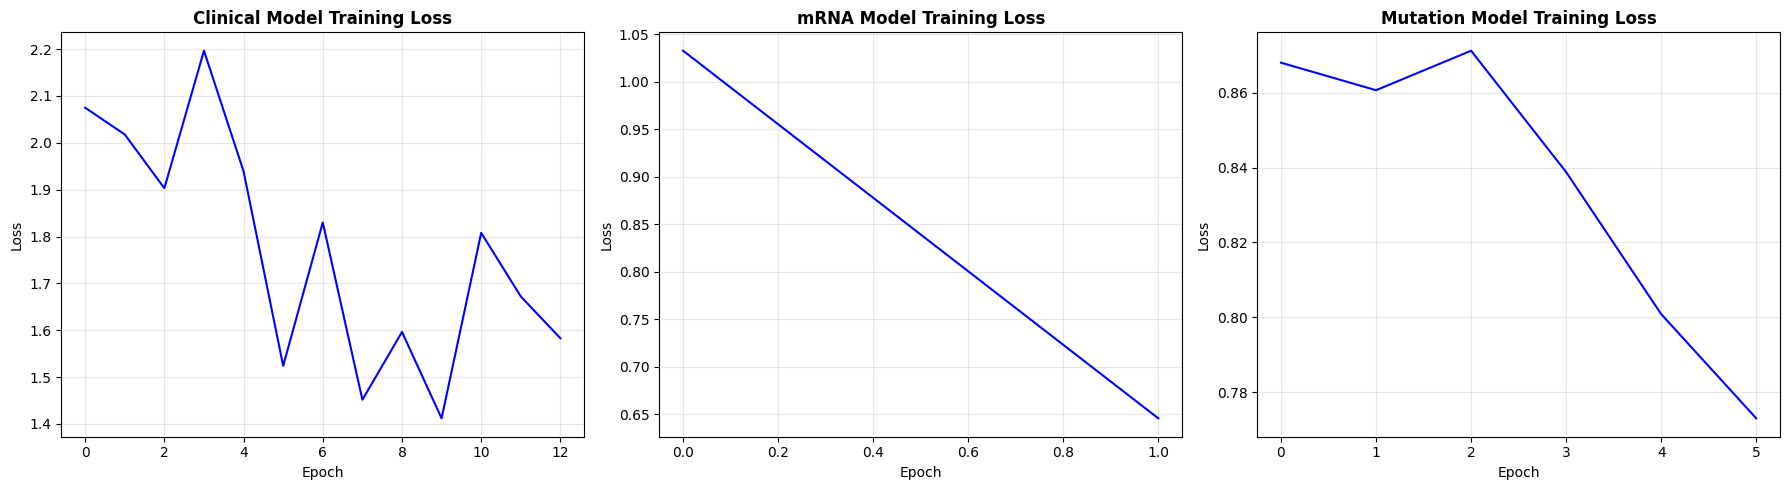

In [50]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Modality': ['Clinical', 'mRNA', 'Mutation'],
    'AUROC': [
        clinical_results['train_metrics']['auroc'],
        mrna_results['train_metrics']['auroc'],
        mutation_results['train_metrics']['auroc']
    ],
    'F1': [
        clinical_results['train_metrics']['f1'],
        mrna_results['train_metrics']['f1'],
        mutation_results['train_metrics']['f1']
    ],
    'AUPRC': [
        clinical_results['train_metrics']['auprc'],
        mrna_results['train_metrics']['auprc'],
        mutation_results['train_metrics']['auprc']
    ],
})

print("\n" + "="*80)
print("SINGLE MODALITY COMPARISON (Training Set)")
print("="*80 + "\n")
print(comparison_df.to_string(index=False))
print("\n" + "="*80 + "\n")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['AUROC', 'F1', 'AUPRC']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    bars = ax.bar(comparison_df['Modality'], comparison_df[metric], color=colors)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} by Modality (Training)', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.3f}',
               ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('single_modality_comparison_training.png', dpi=300, bbox_inches='tight')
print("Saved comparison plot to 'single_modality_comparison_training.png'")
plt.show()

# Plot training loss curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Clinical
axes[0].plot(clinical_results['training_history']['train_losses'], color='blue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Clinical Model Training Loss', fontweight='bold')
axes[0].grid(alpha=0.3)

# mRNA
axes[1].plot(mrna_results['training_history']['train_losses'], color='blue')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('mRNA Model Training Loss', fontweight='bold')
axes[1].grid(alpha=0.3)

# Mutation
axes[2].plot(mutation_results['training_history']['train_losses'], color='blue')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].set_title('Mutation Model Training Loss', fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('single_modality_training_curves.png', dpi=300, bbox_inches='tight')
print("Saved training curves to 'single_modality_training_curves.png'")
plt.show()

## Save Results

In [51]:
# Save comparison table
comparison_df.to_csv('single_modality_training_results.csv', index=False)
print("Saved training results to 'single_modality_training_results.csv'")

# Save models (optional)
torch.save(clinical_results['model'].state_dict(), 'clinical_only_model.pt')
torch.save(mrna_results['model'].state_dict(), 'mrna_only_model.pt')
torch.save(mutation_results['model'].state_dict(), 'mutation_only_model.pt')
print("\nSaved all models!")

Saved training results to 'single_modality_training_results.csv'

Saved all models!


## Test Set Evaluation
**IMPORTANT:** The test data is ONLY used here for final evaluation. It was not used for training, validation, hyperparameter selection, or preprocessing fitting.

LOADING TEST DATA

Test data loaded: 32 samples
Class distribution: 12.0 positive, 20.0 negative

Applying preprocessing transformations (fit on training data)...

Clinical test: 40 features
mRNA test: 17507 features
Mutation test: 9438 features


Evaluating Clinical Model on Test Set

Test Set Metrics:
  AUROC: 0.5667
  F1: 0.4348
  AUPRC: 0.5230
  Threshold (fixed): 0.5000

  Confusion Matrix:
    TN=14, FP=6
    FN=7, TP=5

  Additional Metrics:
    Sensitivity (Recall): 0.4167
    Specificity: 0.7000
    Precision: 0.4545


Evaluating mRNA Model on Test Set

Test Set Metrics:
  AUROC: 0.7458
  F1: 0.6207
  AUPRC: 0.6625
  Threshold (fixed): 0.5000

  Confusion Matrix:
    TN=12, FP=8
    FN=3, TP=9

  Additional Metrics:
    Sensitivity (Recall): 0.7500
    Specificity: 0.6000
    Precision: 0.5294


Evaluating Mutation Model on Test Set

Test Set Metrics:
  AUROC: 0.6958
  F1: 0.0000
  AUPRC: 0.6281
  Threshold (fixed): 0.5000

  Confusion Matrix:
    TN=20, FP=0
    FN=12, TP=0



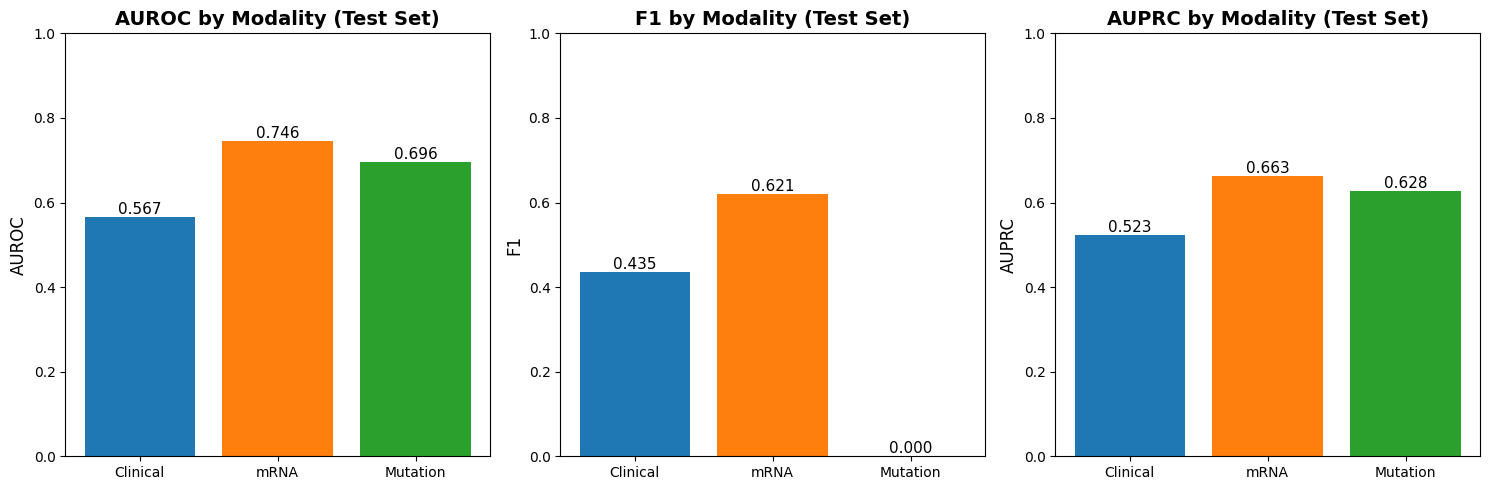


TRAINING vs TEST PERFORMANCE

Modality      Set    AUROC       F1
Clinical Training 0.747290 0.592593
Clinical     Test 0.566667 0.434783
    mRNA Training 0.966279 0.852174
    mRNA     Test 0.745833 0.620690
Mutation Training 0.971297 0.290323
Mutation     Test 0.695833 0.000000


Saved training vs test comparison to 'single_modality_train_vs_test.png'


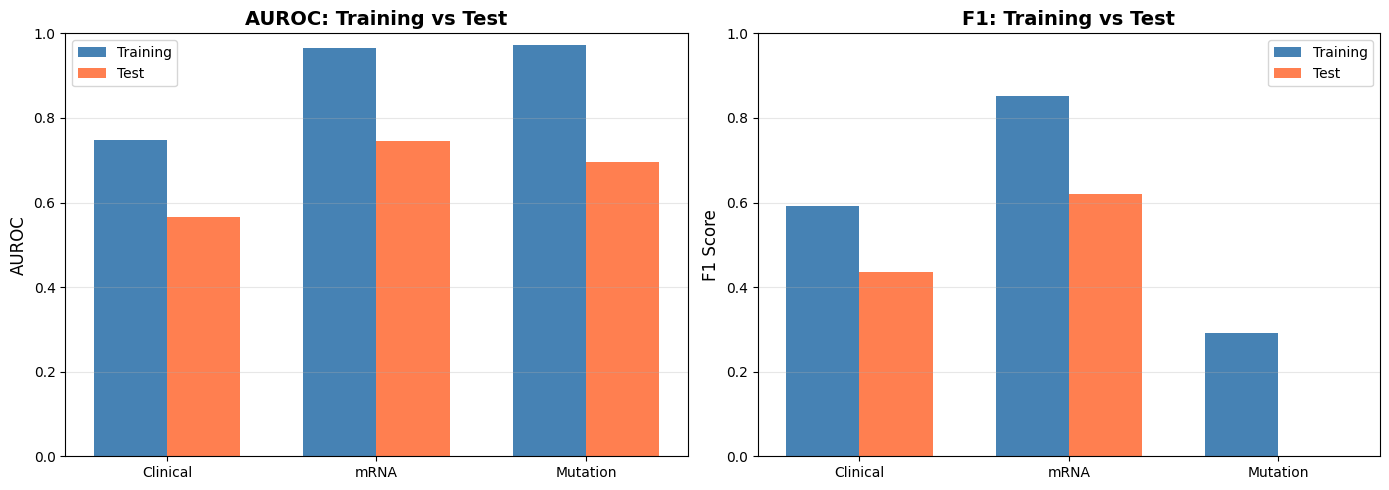


TEST SET EVALUATION COMPLETE


In [52]:
# Load test data
print("="*80)
print("LOADING TEST DATA")
print("="*80 + "\n")

X_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_test.joblib"))
y_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_test.joblib"))

# Split test data by modality
clinical_test = X_test[clinical_cols]
mrna_test = X_test[mrna_cols]
mutation_test = X_test[mutation_cols]

print(f"Test data loaded: {len(X_test)} samples")
print(f"Class distribution: {y_test.sum()} positive, {len(y_test) - y_test.sum()} negative\n")

# IMPORTANT: Apply preprocessing using transformers fit on TRAINING data only
# This prevents data leakage from test set
print("Applying preprocessing transformations (fit on training data)...\n")

clinical_test_prep = clinical_prep.transform(clinical_test)
mrna_test_prep = mrna_prep.transform(mrna_test)
mutation_test_prep = mutation_prep.transform(mutation_test)

print(f"Clinical test: {clinical_test_prep.shape[1]} features")
print(f"mRNA test: {mrna_test_prep.shape[1]} features")
print(f"Mutation test: {mutation_test_prep.shape[1]} features\n")


def evaluate_on_test(model, X_test, y_test, threshold, modality_name):
    """Evaluate a trained model on test data"""
    print(f"\n{'='*80}")
    print(f"Evaluating {modality_name} Model on Test Set")
    print(f"{'='*80}\n")
    
    # Create test loader
    test_loader = to_loader(X_test, y_test, training_config['batch_size'], shuffle=False)
    
    # Predict on test set
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            probs = torch.sigmoid(model(X_batch)).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y_batch.cpu().numpy())
    
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    
    # Calculate metrics
    test_auroc = roc_auc_score(all_labels, all_probs)
    test_auprc = average_precision_score(all_labels, all_probs)
    
    # Use fixed threshold
    preds = (all_probs >= threshold).astype(int)
    test_f1 = f1_score(all_labels, preds, zero_division=0)
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, preds)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate additional metrics
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    print(f"Test Set Metrics:")
    print(f"  AUROC: {test_auroc:.4f}")
    print(f"  F1: {test_f1:.4f}")
    print(f"  AUPRC: {test_auprc:.4f}")
    print(f"  Threshold (fixed): {threshold:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"    TN={tn}, FP={fp}")
    print(f"    FN={fn}, TP={tp}")
    print(f"\n  Additional Metrics:")
    print(f"    Sensitivity (Recall): {sensitivity:.4f}")
    print(f"    Specificity: {specificity:.4f}")
    print(f"    Precision: {precision:.4f}")
    print(f"{'='*80}\n")
    
    return {
        'auroc': test_auroc,
        'auprc': test_auprc,
        'f1': test_f1,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'confusion_matrix': cm,
        'probs': all_probs,
        'labels': all_labels,
    }


# Evaluate each model on test set using fixed threshold
clinical_test_results = evaluate_on_test(
    clinical_results['model'], 
    clinical_test_prep, 
    y_test,
    clinical_results['threshold'],
    "Clinical"
)

mrna_test_results = evaluate_on_test(
    mrna_results['model'], 
    mrna_test_prep, 
    y_test,
    mrna_results['threshold'],
    "mRNA"
)

mutation_test_results = evaluate_on_test(
    mutation_results['model'], 
    mutation_test_prep, 
    y_test,
    mutation_results['threshold'],
    "Mutation"
)

# Create test set comparison table
test_comparison_df = pd.DataFrame({
    'Modality': ['Clinical', 'mRNA', 'Mutation'],
    'AUROC': [
        clinical_test_results['auroc'],
        mrna_test_results['auroc'],
        mutation_test_results['auroc']
    ],
    'F1': [
        clinical_test_results['f1'],
        mrna_test_results['f1'],
        mutation_test_results['f1']
    ],
    'AUPRC': [
        clinical_test_results['auprc'],
        mrna_test_results['auprc'],
        mutation_test_results['auprc']
    ],
    'Sensitivity': [
        clinical_test_results['sensitivity'],
        mrna_test_results['sensitivity'],
        mutation_test_results['sensitivity']
    ],
    'Specificity': [
        clinical_test_results['specificity'],
        mrna_test_results['specificity'],
        mutation_test_results['specificity']
    ],
})

print("\n" + "="*80)
print("TEST SET COMPARISON - FINAL RESULTS")
print("="*80 + "\n")
print(test_comparison_df.to_string(index=False))
print("\n" + "="*80 + "\n")

# Save test results
test_comparison_df.to_csv('single_modality_test_results.csv', index=False)
print("Saved test results to 'single_modality_test_results.csv'\n")

# Visualize test set comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['AUROC', 'F1', 'AUPRC']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    bars = ax.bar(test_comparison_df['Modality'], test_comparison_df[metric], color=colors)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} by Modality (Test Set)', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.3f}',
               ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('single_modality_test_comparison.png', dpi=300, bbox_inches='tight')
print("Saved test comparison plot to 'single_modality_test_comparison.png'")
plt.show()

# Compare training vs test performance
print("\n" + "="*80)
print("TRAINING vs TEST PERFORMANCE")
print("="*80 + "\n")

train_vs_test = pd.DataFrame({
    'Modality': ['Clinical', 'Clinical', 'mRNA', 'mRNA', 'Mutation', 'Mutation'],
    'Set': ['Training', 'Test', 'Training', 'Test', 'Training', 'Test'],
    'AUROC': [
        clinical_results['train_metrics']['auroc'], clinical_test_results['auroc'],
        mrna_results['train_metrics']['auroc'], mrna_test_results['auroc'],
        mutation_results['train_metrics']['auroc'], mutation_test_results['auroc']
    ],
    'F1': [
        clinical_results['train_metrics']['f1'], clinical_test_results['f1'],
        mrna_results['train_metrics']['f1'], mrna_test_results['f1'],
        mutation_results['train_metrics']['f1'], mutation_test_results['f1']
    ],
})

print(train_vs_test.to_string(index=False))
print("\n" + "="*80 + "\n")

# Plot training vs test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modalities = ['Clinical', 'mRNA', 'Mutation']
x = np.arange(len(modalities))
width = 0.35

# AUROC comparison
train_aurocs = [clinical_results['train_metrics']['auroc'], mrna_results['train_metrics']['auroc'], mutation_results['train_metrics']['auroc']]
test_aurocs = [clinical_test_results['auroc'], mrna_test_results['auroc'], mutation_test_results['auroc']]

axes[0].bar(x - width/2, train_aurocs, width, label='Training', color='steelblue')
axes[0].bar(x + width/2, test_aurocs, width, label='Test', color='coral')
axes[0].set_ylabel('AUROC', fontsize=12)
axes[0].set_title('AUROC: Training vs Test', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modalities)
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# F1 comparison
train_f1s = [clinical_results['train_metrics']['f1'], mrna_results['train_metrics']['f1'], mutation_results['train_metrics']['f1']]
test_f1s = [clinical_test_results['f1'], mrna_test_results['f1'], mutation_test_results['f1']]

axes[1].bar(x - width/2, train_f1s, width, label='Training', color='steelblue')
axes[1].bar(x + width/2, test_f1s, width, label='Test', color='coral')
axes[1].set_ylabel('F1 Score', fontsize=12)
axes[1].set_title('F1: Training vs Test', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(modalities)
axes[1].legend()
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('single_modality_train_vs_test.png', dpi=300, bbox_inches='tight')
print("Saved training vs test comparison to 'single_modality_train_vs_test.png'")
plt.show()

print("\n" + "="*80)
print("TEST SET EVALUATION COMPLETE")
print("="*80)

In [53]:
# # Load test data
# print("="*80)
# print("LOADING VALIDATION DATA")
# print("="*80 + "\n")

# X_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_val.joblib"))
# y_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_val.joblib"))

# # Split test data by modality
# clinical_test = X_test[clinical_cols]
# mrna_test = X_test[mrna_cols]
# mutation_test = X_test[mutation_cols]

# print(f"Test data loaded: {len(X_test)} samples")
# print(f"Class distribution: {y_test.sum()} positive, {len(y_test) - y_test.sum()} negative\n")

# # IMPORTANT: Apply preprocessing using transformers fit on TRAINING data only
# # This prevents data leakage from test set
# print("Applying preprocessing transformations (fit on training data)...\n")

# clinical_test_prep = clinical_prep.transform(clinical_test)
# mrna_test_prep = mrna_prep.transform(mrna_test)
# mutation_test_prep = mutation_prep.transform(mutation_test)

# print(f"Clinical test: {clinical_test_prep.shape[1]} features")
# print(f"mRNA test: {mrna_test_prep.shape[1]} features")
# print(f"Mutation test: {mutation_test_prep.shape[1]} features\n")


# def evaluate_on_test(model, X_test, y_test, threshold, modality_name):
#     """Evaluate a trained model on test data"""
#     print(f"\n{'='*80}")
#     print(f"Evaluating {modality_name} Model on Test Set")
#     print(f"{'='*80}\n")
    
#     # Create test loader
#     test_loader = to_loader(X_test, y_test, training_config['batch_size'], shuffle=False)
    
#     # Predict on test set
#     model.eval()
#     all_probs, all_labels = [], []
#     with torch.no_grad():
#         for X_batch, y_batch in test_loader:
#             X_batch = X_batch.to(device)
#             y_batch = y_batch.to(device)
            
#             probs = torch.sigmoid(model(X_batch)).cpu().numpy()
#             all_probs.append(probs)
#             all_labels.append(y_batch.cpu().numpy())
    
#     all_probs = np.concatenate(all_probs)
#     all_labels = np.concatenate(all_labels)
    
#     # Calculate metrics
#     test_auroc = roc_auc_score(all_labels, all_probs)
#     test_auprc = average_precision_score(all_labels, all_probs)
    
#     # Use fixed threshold
#     preds = (all_probs >= threshold).astype(int)
#     test_f1 = f1_score(all_labels, preds, zero_division=0)
    
#     # Confusion matrix
#     cm = confusion_matrix(all_labels, preds)
#     tn, fp, fn, tp = cm.ravel()
    
#     # Calculate additional metrics
#     sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
#     specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
#     precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
#     print(f"Test Set Metrics:")
#     print(f"  AUROC: {test_auroc:.4f}")
#     print(f"  F1: {test_f1:.4f}")
#     print(f"  AUPRC: {test_auprc:.4f}")
#     print(f"  Threshold (fixed): {threshold:.4f}")
#     print(f"\n  Confusion Matrix:")
#     print(f"    TN={tn}, FP={fp}")
#     print(f"    FN={fn}, TP={tp}")
#     print(f"\n  Additional Metrics:")
#     print(f"    Sensitivity (Recall): {sensitivity:.4f}")
#     print(f"    Specificity: {specificity:.4f}")
#     print(f"    Precision: {precision:.4f}")
#     print(f"{'='*80}\n")
    
#     return {
#         'auroc': test_auroc,
#         'auprc': test_auprc,
#         'f1': test_f1,
#         'sensitivity': sensitivity,
#         'specificity': specificity,
#         'precision': precision,
#         'confusion_matrix': cm,
#         'probs': all_probs,
#         'labels': all_labels,
#     }


# # Evaluate each model on test set using fixed threshold
# clinical_test_results = evaluate_on_test(
#     clinical_results['model'], 
#     clinical_test_prep, 
#     y_test,
#     clinical_results['threshold'],
#     "Clinical"
# )

# mrna_test_results = evaluate_on_test(
#     mrna_results['model'], 
#     mrna_test_prep, 
#     y_test,
#     mrna_results['threshold'],
#     "mRNA"
# )

# mutation_test_results = evaluate_on_test(
#     mutation_results['model'], 
#     mutation_test_prep, 
#     y_test,
#     mutation_results['threshold'],
#     "Mutation"
# )

# # Create test set comparison table
# test_comparison_df = pd.DataFrame({
#     'Modality': ['Clinical', 'mRNA', 'Mutation'],
#     'AUROC': [
#         clinical_test_results['auroc'],
#         mrna_test_results['auroc'],
#         mutation_test_results['auroc']
#     ],
#     'F1': [
#         clinical_test_results['f1'],
#         mrna_test_results['f1'],
#         mutation_test_results['f1']
#     ],
#     'AUPRC': [
#         clinical_test_results['auprc'],
#         mrna_test_results['auprc'],
#         mutation_test_results['auprc']
#     ],
#     'Sensitivity': [
#         clinical_test_results['sensitivity'],
#         mrna_test_results['sensitivity'],
#         mutation_test_results['sensitivity']
#     ],
#     'Specificity': [
#         clinical_test_results['specificity'],
#         mrna_test_results['specificity'],
#         mutation_test_results['specificity']
#     ],
# })

# print("\n" + "="*80)
# print("TEST SET COMPARISON - FINAL RESULTS")
# print("="*80 + "\n")
# print(test_comparison_df.to_string(index=False))
# print("\n" + "="*80 + "\n")

# # Save test results
# test_comparison_df.to_csv('single_modality_test_results.csv', index=False)
# print("Saved test results to 'single_modality_test_results.csv'\n")

# # Visualize test set comparison
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# metrics = ['AUROC', 'F1', 'AUPRC']
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# for idx, metric in enumerate(metrics):
#     ax = axes[idx]
#     bars = ax.bar(test_comparison_df['Modality'], test_comparison_df[metric], color=colors)
#     ax.set_ylabel(metric, fontsize=12)
#     ax.set_title(f'{metric} by Modality (Test Set)', fontsize=14, fontweight='bold')
#     ax.set_ylim([0, 1])
    
#     # Add value labels
#     for bar in bars:
#         height = bar.get_height()
#         ax.text(bar.get_x() + bar.get_width()/2., height,
#                f'{height:.3f}',
#                ha='center', va='bottom', fontsize=11)

# plt.tight_layout()
# plt.savefig('single_modality_test_comparison.png', dpi=300, bbox_inches='tight')
# print("Saved test comparison plot to 'single_modality_test_comparison.png'")
# plt.show()

# # Compare training vs test performance
# print("\n" + "="*80)
# print("TRAINING vs TEST PERFORMANCE")
# print("="*80 + "\n")

# train_vs_test = pd.DataFrame({
#     'Modality': ['Clinical', 'Clinical', 'mRNA', 'mRNA', 'Mutation', 'Mutation'],
#     'Set': ['Training', 'Test', 'Training', 'Test', 'Training', 'Test'],
#     'AUROC': [
#         clinical_results['train_metrics']['auroc'], clinical_test_results['auroc'],
#         mrna_results['train_metrics']['auroc'], mrna_test_results['auroc'],
#         mutation_results['train_metrics']['auroc'], mutation_test_results['auroc']
#     ],
#     'F1': [
#         clinical_results['train_metrics']['f1'], clinical_test_results['f1'],
#         mrna_results['train_metrics']['f1'], mrna_test_results['f1'],
#         mutation_results['train_metrics']['f1'], mutation_test_results['f1']
#     ],
# })

# print(train_vs_test.to_string(index=False))
# print("\n" + "="*80 + "\n")

# # Plot training vs test
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# modalities = ['Clinical', 'mRNA', 'Mutation']
# x = np.arange(len(modalities))
# width = 0.35

# # AUROC comparison
# train_aurocs = [clinical_results['train_metrics']['auroc'], mrna_results['train_metrics']['auroc'], mutation_results['train_metrics']['auroc']]
# test_aurocs = [clinical_test_results['auroc'], mrna_test_results['auroc'], mutation_test_results['auroc']]

# axes[0].bar(x - width/2, train_aurocs, width, label='Training', color='steelblue')
# axes[0].bar(x + width/2, test_aurocs, width, label='Test', color='coral')
# axes[0].set_ylabel('AUROC', fontsize=12)
# axes[0].set_title('AUROC: Training vs Test', fontsize=14, fontweight='bold')
# axes[0].set_xticks(x)
# axes[0].set_xticklabels(modalities)
# axes[0].legend()
# axes[0].set_ylim([0, 1])
# axes[0].grid(axis='y', alpha=0.3)

# # F1 comparison
# train_f1s = [clinical_results['train_metrics']['f1'], mrna_results['train_metrics']['f1'], mutation_results['train_metrics']['f1']]
# test_f1s = [clinical_test_results['f1'], mrna_test_results['f1'], mutation_test_results['f1']]

# axes[1].bar(x - width/2, train_f1s, width, label='Training', color='steelblue')
# axes[1].bar(x + width/2, test_f1s, width, label='Test', color='coral')
# axes[1].set_ylabel('F1 Score', fontsize=12)
# axes[1].set_title('F1: Training vs Test', fontsize=14, fontweight='bold')
# axes[1].set_xticks(x)
# axes[1].set_xticklabels(modalities)
# axes[1].legend()
# axes[1].set_ylim([0, 1])
# axes[1].grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.savefig('single_modality_train_vs_test.png', dpi=300, bbox_inches='tight')
# print("Saved training vs test comparison to 'single_modality_train_vs_test.png'")
# plt.show()

# print("\n" + "="*80)
# print("TEST SET EVALUATION COMPLETE")
# print("="*80)

SHAP FEATURE IMPORTANCE ANALYSIS

Clinical features: 40
mRNA features: 17507
Mutation features: 9438

Running SHAP analysis on Clinical model...

SHAP Analysis: Clinical

Using 32 samples as background
Explaining 32 samples

Creating SHAP explainer...
Calculating SHAP values (this may take a few minutes)...


  0%|          | 0/32 [00:00<?, ?it/s]

SHAP values calculated!

Creating beeswarm plot...


/tmp/ipykernel_1911973/61478421.py:86: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Saved beeswarm plot to 'shap_clinical_beeswarm.png'


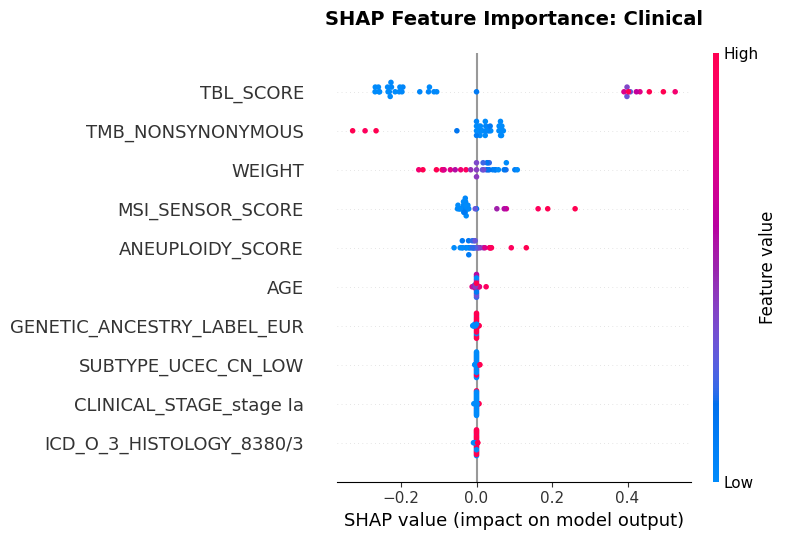

Creating feature importance bar plot...


/tmp/ipykernel_1911973/61478421.py:103: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Saved bar plot to 'shap_clinical_bar.png'


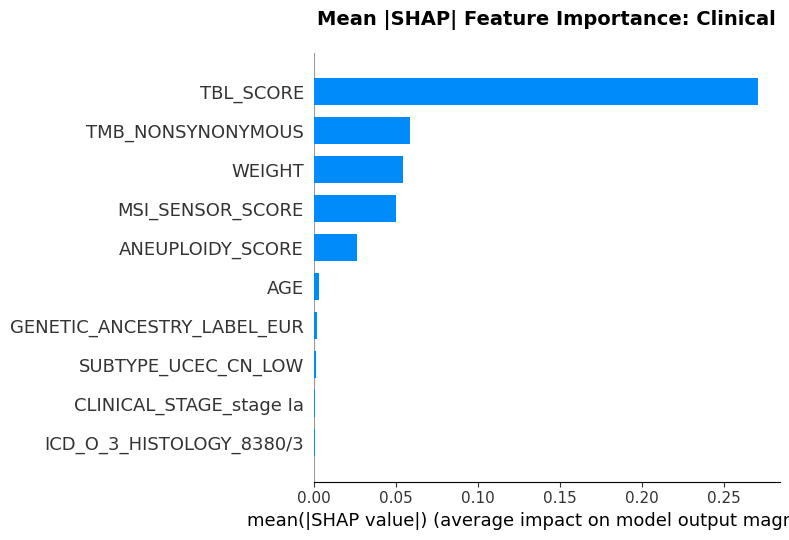


Top 10 Most Important Features for Clinical:
  1. TBL_SCORE: 0.2706
  2. TMB_NONSYNONYMOUS: 0.0586
  3. WEIGHT: 0.0548
  4. MSI_SENSOR_SCORE: 0.0504
  5. ANEUPLOIDY_SCORE: 0.0267
  6. AGE: 0.0030
  7. GENETIC_ANCESTRY_LABEL_EUR: 0.0021
  8. SUBTYPE_UCEC_CN_LOW: 0.0015
  9. CLINICAL_STAGE_stage Ia: 0.0011
  10. ICD_O_3_HISTOLOGY_8380/3: 0.0009


Running SHAP analysis on mRNA model...

SHAP Analysis: mRNA

Using 32 samples as background
Explaining 32 samples

Creating SHAP explainer...
Calculating SHAP values (this may take a few minutes)...


  0%|          | 0/32 [00:00<?, ?it/s]

/oscar/home/gchermsi/env-with-ray-py/lib/python3.11/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 1 iterations, i.e. alpha=3.378e-01, with an active set of 1 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/oscar/home/gchermsi/env-with-ray-py/lib/python3.11/site-packages/shap/explainers/_kernel.py:708: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up the L1 regularization with num_features(N) where N is less than the number of samples,
3) group features together to reduce the number of inputs that need to be explained.
  warnings.warn(
/oscar/home/gchermsi/env-with-ray-py/lib/python3.11/site-packages/sklearn/linear_model/_least_angle.py:723: Converg

SHAP values calculated!

Creating beeswarm plot...


/tmp/ipykernel_1911973/61478421.py:86: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Saved beeswarm plot to 'shap_mrna_beeswarm.png'


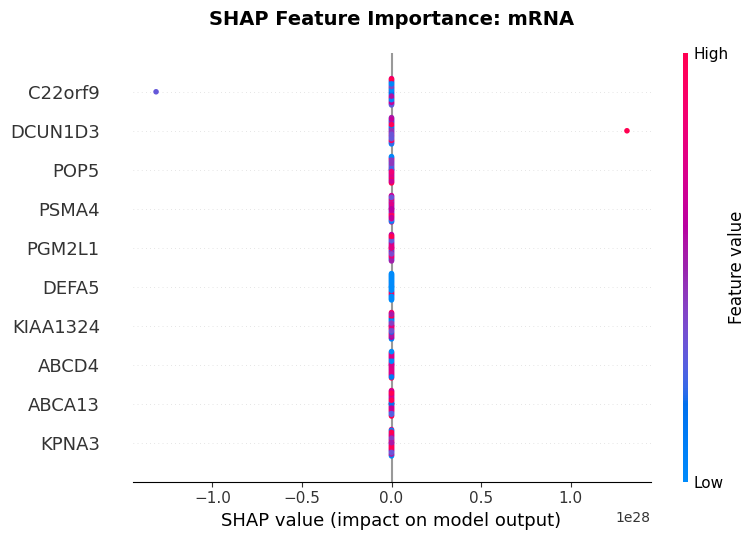

Creating feature importance bar plot...


/tmp/ipykernel_1911973/61478421.py:103: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Saved bar plot to 'shap_mrna_bar.png'


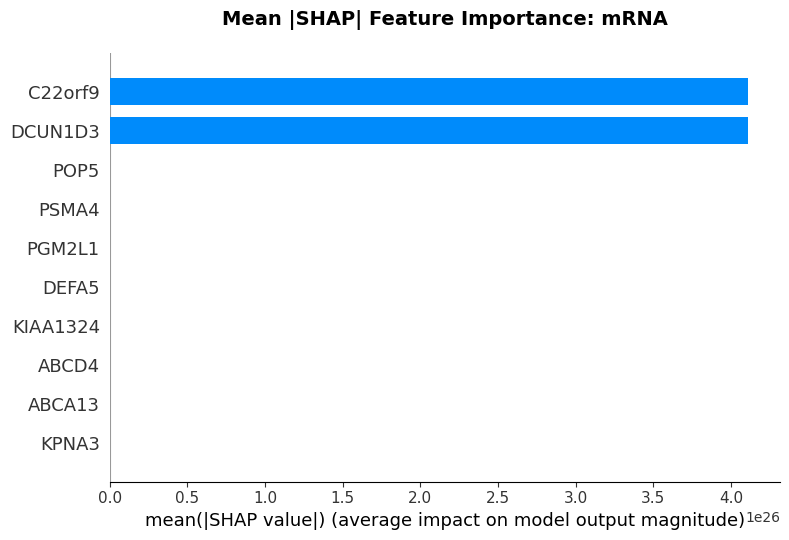


Top 10 Most Important Features for mRNA:
  1. C22orf9: 410991620964291668929937408.0000
  2. DCUN1D3: 410991620964291531490983936.0000
  3. POP5: 147743771854.6026
  4. PSMA4: 142591362663.3038
  5. PGM2L1: 142591362663.3021
  6. DEFA5: 17849759957.0643
  7. KIAA1324: 8924879978.5321
  8. ABCD4: 0.0140
  9. ABCA13: 0.0109
  10. KPNA3: 0.0098


Running SHAP analysis on Mutation model...

SHAP Analysis: Mutation

Using 32 samples as background
Explaining 32 samples

Creating SHAP explainer...
Calculating SHAP values (this may take a few minutes)...


  0%|          | 0/32 [00:00<?, ?it/s]

/oscar/home/gchermsi/env-with-ray-py/lib/python3.11/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=6.846e-02, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/oscar/home/gchermsi/env-with-ray-py/lib/python3.11/site-packages/shap/explainers/_kernel.py:708: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up the L1 regularization with num_features(N) where N is less than the number of samples,
3) group features together to reduce the number of inputs that need to be explained.
  warnings.warn(
/oscar/home/gchermsi/env-with-ray-py/lib/python3.11/site-packages/sklearn/linear_model/_least_angle.py:723: Converg

SHAP values calculated!

Creating beeswarm plot...


/tmp/ipykernel_1911973/61478421.py:86: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Saved beeswarm plot to 'shap_mutation_beeswarm.png'


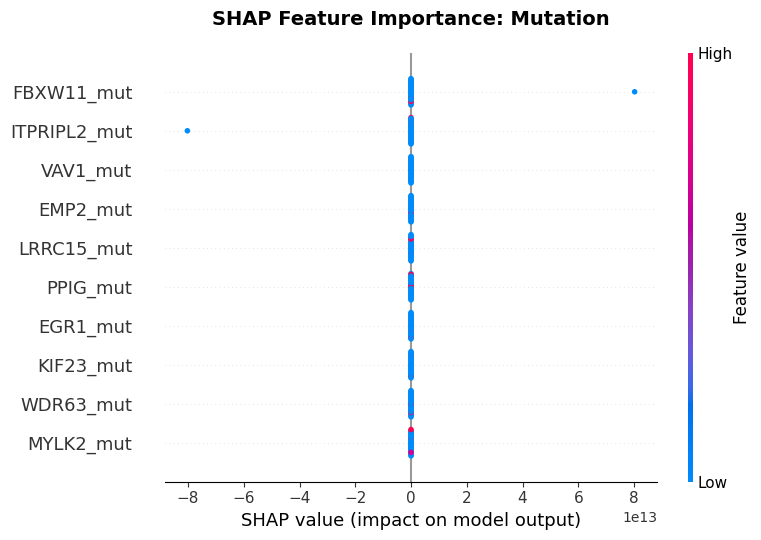

Creating feature importance bar plot...


/tmp/ipykernel_1911973/61478421.py:103: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Saved bar plot to 'shap_mutation_bar.png'


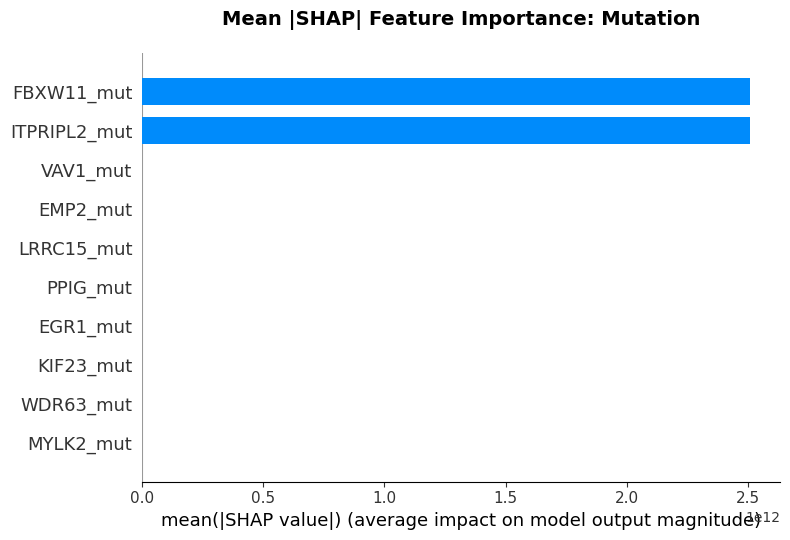


Top 10 Most Important Features for Mutation:
  1. FBXW11_mut: 2506920785714.5933
  2. ITPRIPL2_mut: 2506920785714.5933
  3. VAV1_mut: 0.0048
  4. EMP2_mut: 0.0033
  5. LRRC15_mut: 0.0030
  6. PPIG_mut: 0.0028
  7. EGR1_mut: 0.0028
  8. KIF23_mut: 0.0027
  9. WDR63_mut: 0.0022
  10. MYLK2_mut: 0.0021



SHAP ANALYSIS COMPLETE


In [54]:
import shap

print("="*80)
print("SHAP FEATURE IMPORTANCE ANALYSIS")
print("="*80 + "\n")

# Model wrapper for SHAP that handles PyTorch models
class ModelWrapper:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        self.model.eval()
    
    def predict(self, X):
        """Predict probabilities for SHAP"""
        with torch.no_grad():
            X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
            logits = self.model(X_tensor)
            probs = torch.sigmoid(logits).cpu().numpy()
            
            # Ensure probs is at least 1-dimensional
            if probs.ndim == 0:
                probs = np.array([probs])
            elif probs.ndim == 1:
                probs = probs.reshape(-1)
            
        return probs


def run_shap_analysis(model, X_data, feature_names, modality_name, background_size=100, explain_size=100):
    """
    Run SHAP analysis on a model
    
    Parameters:
    - model: Trained PyTorch model
    - X_data: Test data (numpy array or DataFrame)
    - feature_names: List of feature names
    - modality_name: Name of the modality (for plot titles)
    - background_size: Number of samples to use as background
    - explain_size: Number of samples to explain
    """
    print(f"\n{'='*80}")
    print(f"SHAP Analysis: {modality_name}")
    print(f"{'='*80}\n")
    
    # Convert to numpy if needed
    if isinstance(X_data, pd.DataFrame):
        X_numpy = X_data.to_numpy(dtype=np.float32)
    else:
        X_numpy = np.array(X_data, dtype=np.float32)
    
    # Sample background data for SHAP
    np.random.seed(config.SEED)
    if len(X_numpy) > background_size:
        background_indices = np.random.choice(len(X_numpy), background_size, replace=False)
        background = X_numpy[background_indices]
    else:
        background = X_numpy
    
    # Sample data to explain
    if len(X_numpy) > explain_size:
        explain_indices = np.random.choice(len(X_numpy), explain_size, replace=False)
        X_explain = X_numpy[explain_indices]
    else:
        X_explain = X_numpy
    
    print(f"Using {len(background)} samples as background")
    print(f"Explaining {len(X_explain)} samples")
    
    # Create model wrapper
    model_wrapper = ModelWrapper(model, device)
    
    # Create SHAP explainer (using KernelExplainer for model-agnostic approach)
    print("\nCreating SHAP explainer...")
    explainer = shap.KernelExplainer(model_wrapper.predict, background)
    
    # Calculate SHAP values
    print("Calculating SHAP values (this may take a few minutes)...")
    shap_values = explainer.shap_values(X_explain, nsamples=100)
    
    print("SHAP values calculated!\n")
    
    # Create beeswarm plot
    print("Creating beeswarm plot...")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values, 
        X_explain, 
        feature_names=feature_names,
        max_display=10,
        show=False
    )
    plt.title(f'SHAP Feature Importance: {modality_name}', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    filename = f'shap_{modality_name.lower()}_beeswarm.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved beeswarm plot to '{filename}'")
    plt.show()
    
    # Create bar plot of mean absolute SHAP values
    print("Creating feature importance bar plot...")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values, 
        X_explain, 
        feature_names=feature_names,
        plot_type="bar",
        max_display=10,
        show=False
    )
    plt.title(f'Mean |SHAP| Feature Importance: {modality_name}', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    filename = f'shap_{modality_name.lower()}_bar.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved bar plot to '{filename}'")
    plt.show()
    
    # Get top features
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_indices = np.argsort(mean_abs_shap)[::-1][:10]
    
    print(f"\nTop 10 Most Important Features for {modality_name}:")
    for i, idx in enumerate(top_indices, 1):
        print(f"  {i}. {feature_names[idx]}: {mean_abs_shap[idx]:.4f}")
    
    print(f"\n{'='*80}\n")
    
    return shap_values


# Get feature names from preprocessed data
clinical_feature_names = list(clinical_train_prep.columns) if isinstance(clinical_train_prep, pd.DataFrame) else [f"clinical_{i}" for i in range(clinical_train_prep.shape[1])]
mrna_feature_names = list(mrna_train_prep.columns) if isinstance(mrna_train_prep, pd.DataFrame) else [f"mrna_{i}" for i in range(mrna_train_prep.shape[1])]
mutation_feature_names = list(mutation_train_prep.columns) if isinstance(mutation_train_prep, pd.DataFrame) else [f"mutation_{i}" for i in range(mutation_train_prep.shape[1])]

print(f"Clinical features: {len(clinical_feature_names)}")
print(f"mRNA features: {len(mrna_feature_names)}")
print(f"Mutation features: {len(mutation_feature_names)}\n")

# Run SHAP analysis for each modality
# Using test data for SHAP (since models were trained on training data)

print("Running SHAP analysis on Clinical model...")
clinical_shap_values = run_shap_analysis(
    clinical_results['model'],
    clinical_test_prep,
    clinical_feature_names,
    "Clinical",
    background_size=50,
    explain_size=50
)

print("Running SHAP analysis on mRNA model...")
mrna_shap_values = run_shap_analysis(
    mrna_results['model'],
    mrna_test_prep,
    mrna_feature_names,
    "mRNA",
    background_size=50,
    explain_size=50
)

print("Running SHAP analysis on Mutation model...")
mutation_shap_values = run_shap_analysis(
    mutation_results['model'],
    mutation_test_prep,
    mutation_feature_names,
    "Mutation",
    background_size=50,
    explain_size=50
)

print("\n" + "="*80)
print("SHAP ANALYSIS COMPLETE")
print("="*80)